Pneumonia Detection using Resnet50(Tensorflow library)

In [7]:

#Step-1:- Import Necessary Libraries
import numpy as np
import os

#Step-2:- Read and explore the data 
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories=["NORMAL","PNEUMONIA"]
for category in categories:
    print(category,":",len(os.listdir(os.path.join(train_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(val_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(test_dir,category))))

#step-3:- preprocessing the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#for augmentation and rescaling(converting to array)the data
train_gen=ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True
)

val_gen=ImageDataGenerator(
    rescale=1./255
)

test_gen=ImageDataGenerator(
    rescale=1./255
)

#read images and label the image and load the image  
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

val_data=val_gen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

#Step-4:- Defining the model architecture 
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers,models
#making the base of resnet 50, already pretrained
resnet50_base=ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
#taking the pretrained layers without training by ownself
for layer in resnet50_base.layers:
    layer.trainable=False

model=models.Sequential([
    resnet50_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid")
])

#Step-5:- Compiling the model
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

#Step-6:- Training the model
history=model.fit(train_data,epochs=5,validation_data=val_data)

#Step-7:- Evaluating the model
test_loss,test_accuracy=model.evaluate(test_data)
print("Test Accuracy:- ",test_accuracy)

#Step-8:- Prediction on new image
from tensorflow.keras.preprocessing import image 
path="/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg"
img=image.load_img(path,target_size=(224,224))
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)
prediction=model.predict(img_array)
print("Diagnosis","Pneumonia" if prediction[0][0]>0.5 else "Normal")

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.6893 - loss: 0.6463 - val_accuracy: 0.5000 - val_loss: 0.8587
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 489s 3s/step - accuracy: 0.7343 - loss: 0.5750 - val_accuracy: 0.5000 - val_loss: 0.8164
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 482s 3s/step - accuracy: 0.7410 - loss: 0.5483 - val_accuracy: 0.5000 - val_loss: 0.7558
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 487s 3s/step - accuracy: 0.7472 - loss: 0.5184 - val_accuracy: 0.5000 - val_loss: 0.8196
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.7500 - loss: 0.5035 - val_accuracy: 0.5000 - val_loss: 0.8639
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.6490 - loss: 0.6199
Test Accuracy:-  0.6266025900840759


AttributeError: module 'tensorflow.keras.preprocessing.image' has no attribute 'img_array'

Pneumonia Detection using Resnet50(Pytorch library)

In [1]:
#Step-1:- Import Necessary library
import numpy as np
import torch
import os

#Step-2:- Load and explore the data 
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories=["NORMAL","PNEUMONIA"]
for category in categories:
    print(category,":",len(os.listdir(os.path.join(train_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(val_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(test_dir,category))))

#Step-3:- Preprocessing the data 
from torchvision import transforms,datasets
#for augmentation and transforming the data into vector data 
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

#read the image and label the image
train_data=datasets.ImageFolder(train_dir,transform=train_transform)
val_data=datasets.ImageFolder(val_dir,transform=val_transform)
test_data=datasets.ImageFolder(test_dir,transform=test_transform)

#load the image 
from torch.utils.data import DataLoader
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
val_loader=DataLoader(val_data,batch_size=32,shuffle=False)
test_loader=DataLoader(test_data,batch_size=32,shuffle=False)

#Step-4:- Device selection
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:- ",device)

#Step-5:- defining the model architecture
from torchvision import models
model=models.resnet50(pretrained=True)

#using pretrained features rather than trainign by own
for param in model.parameters():
    param.requires_grad=True

#making the model
import torch.nn as nn
model.fc=nn.Sequential(
    nn.Linear(model.fc.in_features,256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,1),
    nn.Sigmoid()
)
model.to(device)

#Step-6:- Compiling the model by loss function and optimizer
import torch.optim as optim
criterion=nn.BCELoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

#Step-7:- Training the model
epochs=5
for epoch in range(epochs):
    print(f"Epoch: {epoch+1}/{epochs} started")
    model.train()
    running_loss=0
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    print(f"Epoch: {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f}")

#Step-8:- Evaluating the model
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        predicted=(outputs.squeeze()==labels).sum().item()
        correct+=(predicted>0.5).int()
        total+=labels.size(0)
print("Test accuracy:- ",correct/total)

#Step-9:- Prediction on new image
from PIL import Image
img=Image.open("/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg").convert("RGB")
img_transform=val_transform(img)
real_img=img_transform.unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    outputs=model(real_img)
if (outputs>0.5):
    prediction="Pneumonia"
else:
    prediction="Normal"
print("Diagnosis",prediction)

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390
Using Device:-  cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s] 


Epoch: 1/10 started
Epoch: 1/10 | Loss: 0.2490
Epoch: 2/10 started
Epoch: 2/10 | Loss: 0.1747
Epoch: 3/10 started
Epoch: 3/10 | Loss: 0.1656
Epoch: 4/10 started
Epoch: 4/10 | Loss: 0.1528
Epoch: 5/10 started
Epoch: 5/10 | Loss: 0.1409
Epoch: 6/10 started
Epoch: 6/10 | Loss: 0.1450
Epoch: 7/10 started
Epoch: 7/10 | Loss: 0.1441
Epoch: 8/10 started
Epoch: 8/10 | Loss: 0.1366
Epoch: 9/10 started
Epoch: 9/10 | Loss: 0.1293
Epoch: 10/10 started
Epoch: 10/10 | Loss: 0.1296


AttributeError: 'bool' object has no attribute 'int'

Pneumonia detection using DenseNet121(PyTorch library)

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390


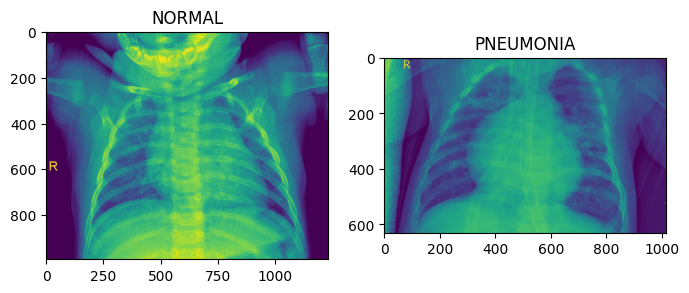

using device:-  cpu
Epoch 1/5 running
Epoch: 1/5 | Loss: 0.2482
Epoch 2/5 running
Epoch: 2/5 | Loss: 0.1519
Epoch 3/5 running
Epoch: 3/5 | Loss: 0.1595
Epoch 4/5 running
Epoch: 4/5 | Loss: 0.1430
Epoch 5/5 running
Epoch: 5/5 | Loss: 0.1365
Accuracy:-  0.780448717948718


AttributeError: module 'PIL.Image' has no attribute 'Open'

In [12]:
## Step-1:- Import necesssary library
import numpy as np
import torch
import os

#Step-2:- Load and explore the data 
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories=["NORMAL","PNEUMONIA"]
for category in categories:
    print(category,":",len(os.listdir(os.path.join(train_dir,category))))
for category in categories:
    print(category,":",len(os.listdir(os.path.join(val_dir,category))))
for category in categories:
    print(category,":",len(os.listdir(os.path.join(test_dir,category))))

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

path1=os.path.join(train_dir,categories[0])
path1=os.path.join(path1,os.listdir(path1)[100])
path2=os.path.join(train_dir,categories[1])
path2=os.path.join(path2,os.listdir(path2)[100])

img1=mpimg.imread(path1)
img2=mpimg.imread(path2)

fig,ax=plt.subplots(1,2,figsize=(8,12))
ax[0].set_title("NORMAL")
ax[0].imshow(img1)
ax[1].set_title("PNEUMONIA")
ax[1].imshow(img2)
plt.show()

#Step-3: Pre3processing the data
#for augmentation and transforming into vector data 
from torchvision import datasets,transforms
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])
val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

#read and label the data 
train_data=datasets.ImageFolder(train_dir,transform=train_transform)
val_data=datasets.ImageFolder(val_dir,transform=val_transform)
test_data=datasets.ImageFolder(test_dir,transform=test_transform)

#load the data 
from torch.utils.data import DataLoader
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
val_loader=DataLoader(val_data,batch_size=32,shuffle=False)
test_loader=DataLoader(test_data,batch_size=32,shuffle=False)

#Step-4:- Device selection
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:- ",device)

#Step-5:- Defining the model architecture

#for using Densenet 121 mode without taking its top layer
from torchvision import models
model=models.densenet121(pretrained=True)

#using pretrained layers and not to train the model by ownself
for param in model.parameters():
     param.requires_grad=False
    
#making the model based on our need 
import torch.nn as nn
model.classifier=nn.Sequential(
    nn.Linear(model.classifier.in_features,256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,1),
    nn.Sigmoid()
)
model.to(device)

#Step-6:- Compiling the model by loss funcxtion and optimizer
import torch.optim as optim
criterion=nn.BCELoss()
optimizer=optim.Adam(model.classifier.parameters(),lr=0.001)

#Step-7:- tyraining the model
epochs=5
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs} running")
    running_loss=0
    model.train()
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    print(f"Epoch: {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f}")

#Step-8:- Evaluating the model
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        predicted=(outputs>0.5).int()
        correct+=(predicted.squeeze()==labels).sum().item()
        total+=labels.size(0)
accuracy=correct/total
print("Accuracy:- ",accuracy)

#Step-9:- Prediction on new test image
from PIL import Image
img=Image.open("/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg").convert("RGB")
img_transform=val_transform(img)
img=img_transform.unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    outputs=model(img)
if outputs>0.5:
    prediction="Pneumonia"
else:
    prediction="NOrmal"
print("Diagnosis",prediction)

Pneumonia detection using DenseNet121(tensorflow library)

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390


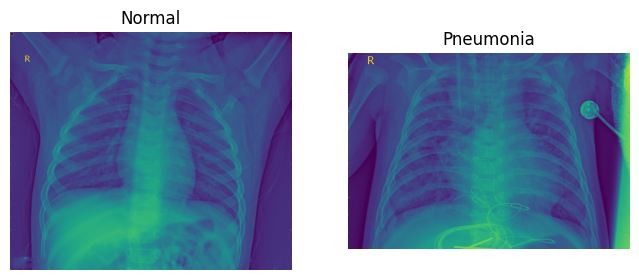

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.7337 - loss: 0.5501 - val_accuracy: 0.6875 - val_loss: 0.6343
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 409s 3s/step - accuracy: 0.9092 - loss: 0.2394 - val_accuracy: 0.6875 - val_loss: 0.5043
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 445s 3s/step - accuracy: 0.9233 - loss: 0.1924 - val_accuracy: 0.8750 - val_loss: 0.3800
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.9272 - loss: 0.1854 - val_accuracy: 0.7500 - val_loss: 0.4199
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.9355 - loss: 0.1677 - val_accuracy: 0.6875 - val_loss: 0.5087
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7139 - loss: 0.5728
Test Accuracy: 0.8333333134651184
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Diagnosis: Pneumonia


In [14]:
# Step-1: Import necessary libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Step-2: Load and explore the data
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

categories = ["NORMAL", "PNEUMONIA"]

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(train_dir, category))))

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(val_dir, category))))

for category in categories:
    print(category, ":", len(os.listdir(os.path.join(test_dir, category))))

# Visualize sample images
path1 = os.path.join(train_dir, categories[0], os.listdir(os.path.join(train_dir, categories[0]))[0])
path2 = os.path.join(train_dir, categories[1], os.listdir(os.path.join(train_dir, categories[1]))[0])

img1 = imread(path1)
img2 = imread(path2)

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].set_title("Normal")
ax[0].imshow(img1)
ax[0].axis("off")

ax[1].set_title("Pneumonia")
ax[1].imshow(img2)
ax[1].axis("off")

plt.show()

# Step-3: Preprocessing the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# Step-4: Defining the model architecture
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import models, layers

densenet121_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in densenet121_base.layers:
    layer.trainable = False

model = models.Sequential([
    densenet121_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Step-5: Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Step-6: Train the model
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

# Step-7: Evaluate the model
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

# Step-8: Prediction on a new image
from tensorflow.keras.preprocessing import image

path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg" 

img = image.load_img(path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Diagnosis:", "Pneumonia" if prediction[0][0] > 0.5 else "Normal")
